<a href="https://colab.research.google.com/github/Saransh-Basu-01/50-Ml-Projects-to-understand-LLMs/blob/main/Project_6_Tokenization_Compression_in_different_languages.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Part_1:Compression in different Languages

## Task 1:
- In a for-loop over the translations, count the number of characters,
bytes, and GPT-2 tokens, and store the results in lists (you’ll need
the data to visualize later).
Print out the decoded tokens to ensure accuracy of the encod
ing.
Generate the table below and compare the results across lan
guages.


In [3]:
from transformers import AutoTokenizer
tokenizer=AutoTokenizer.from_pretrained('gpt2')

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [4]:

# Google-translated ;)
sentences = [
    ['English',   "In Penny Lane, there is a barber showing photographs of every head he's had the pleasure to have known. And all the people that come and go stop and say hello."],
    ['Spanish',   "En Penny Lane hay un barbero que muestra fotografías de todas las personas que ha tenido el placer de conocer. Y todas las personas que van y vienen se detienen y dicen hola."],
    ['Arabic',    "في شارع بيني لين، يوجد حلاق يعرض صورًا لكل شخص كان له شرف معرفته. وكل الناس الذين يأتون ويذهبون يتوقفون ويقولون مرحبًا."],
    ['Persian',   "در خیابان پنی لین، یک آرایشگر وجود دارد که عکس‌های تمام افرادی را که افتخار آشنایی با آن‌ها را داشته به نمایش می‌گذارد. و همهٔ کسانی که می‌آیند و می‌روند می‌ایستند و سلام می‌کنند."],
    ['Lithuanian',"Penny Lane gatvėje yra kirpėjas, rodantis nuotraukas visų žmonių, kuriuos jam teko su malonumu pažinti. Ir visi žmonės, kurie ateina ir išeina, sustoja ir pasisveikina."],
    ['Chinese',   "在彭尼巷，有一位理发师正在展示他曾有幸认识的每一个人的照片。所有来来往往的人都会停下来打招呼。"],
    ['Tamil',     "பென்னி லேனில், தான் அறிந்த ஒவ்வொருவரையும் அறிந்ததற்கான மகிழ்ச்சியுடன் அவர்களின் புகைப்படங்களை காட்டும் ஒரு முடி திருத்துபவர் இருக்கிறார். வரவும் போகவும் 하는 அனைத்து மக்களும் நின்று வணக்கம் சொல்கிறார்கள்."],
    ['Hebrew',    "בפני ליין יש ספר שמציג תמונות של כל אדם שהיה לו העונג להכיר. וכל האנשים שבאים והולכים עוצרים ואומרים שלום."],
            ]

In [8]:
tokens_count=[]
byte_count=[]
char_count=[]
table = ''
for lang,txt in sentences:
  tokens_count.append(len(tokenizer.encode(txt)))
  byte_count.append(len(txt.encode('utf-8')))
  char_count.append(len(txt))

  table += f'{lang:>10} |   {char_count[-1]:3}   |   {byte_count[-1]:3}   |  {tokens_count[-1]:3}\n'

In [9]:
print(' Language  |  Chars  |  Bytes  |  Tokens ')
print('-----------+---------+---------+---------')
print(table)


 Language  |  Chars  |  Bytes  |  Tokens 
-----------+---------+---------+---------
   English |   159   |   159   |   36
   Spanish |   174   |   175   |   61
    Arabic |   119   |   215   |  130
   Persian |   179   |   330   |  215
Lithuanian |   168   |   177   |   84
   Chinese |    47   |   141   |   94
     Tamil |   202   |   558   |  557
    Hebrew |   106   |   191   |  122



# Part_2:Visualization

## Task_1:
- Write code to create Figure 2.18. Each letter in the plot is the first
letter of a language. To use a letter as a marker in a plot, you can
use either plt.text() or plt.plot() with the marker specified using
latex formatting (a letter surrounded by dollar signs).

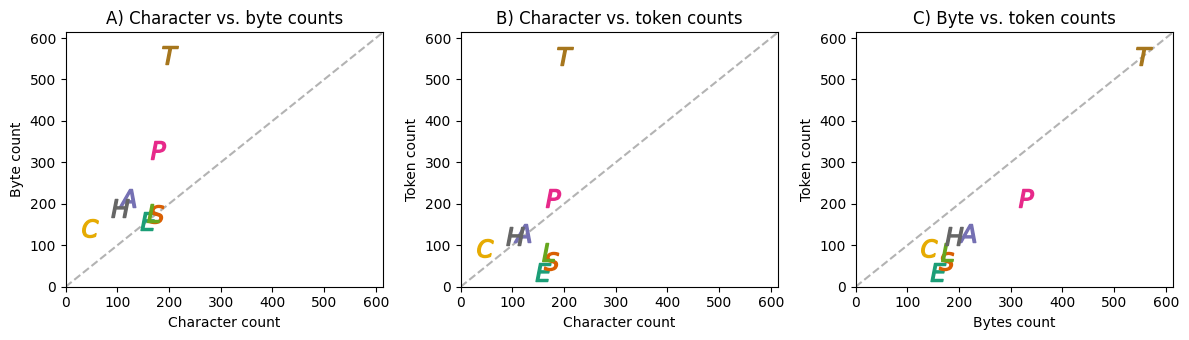

In [11]:
fig,axs = plt.subplots(1,3,figsize=(12,3.5))

# for axis limits
maxCount = 1.1 * np.max([np.max(char_count),np.max(byte_count),np.max(tokens_count)])

for i in range(len(sentences)):

  # extract the first letter of the language
  langMark = rf'${sentences[i][0][0]}$'

  # plot characters by bytes
  axs[0].plot(char_count[i],byte_count[i],marker=langMark,
           markersize=13,color=plt.cm.Dark2(i/len(sentences)))

  # characters by tokens
  axs[1].plot(char_count[i],tokens_count[i],marker=langMark,
           markersize=13,color=plt.cm.Dark2(i/len(sentences)))

  # bytes by tokens
  axs[2].plot(byte_count[i],tokens_count[i],marker=langMark,
           markersize=13,color=plt.cm.Dark2(i/len(sentences)))


for a in axs:
  a.plot([0,maxCount],[0,maxCount],
         '--',color=[.7,.7,.7],zorder=-23)

axs[0].set(xlabel='Character count',ylabel='Byte count',xlim=[0,maxCount],ylim=[0,maxCount],
           title='A) Character vs. byte counts')
axs[1].set(xlabel='Character count',ylabel='Token count',xlim=[0,maxCount],ylim=[0,maxCount],
           title='B) Character vs. token counts')
axs[2].set(xlabel='Bytes count',ylabel='Token count',xlim=[0,maxCount],ylim=[0,maxCount],
           title='C) Byte vs. token counts')

plt.tight_layout()
plt.show()
